# Retrieval augmented generation
 
In retrieval augmented generation (RAG), an LLM retrieves contextual documents from an external dataset as part of its execution. 

This is useful if we want to ask question about specific documents (e.g., our PDFs, a set of videos, etc). 

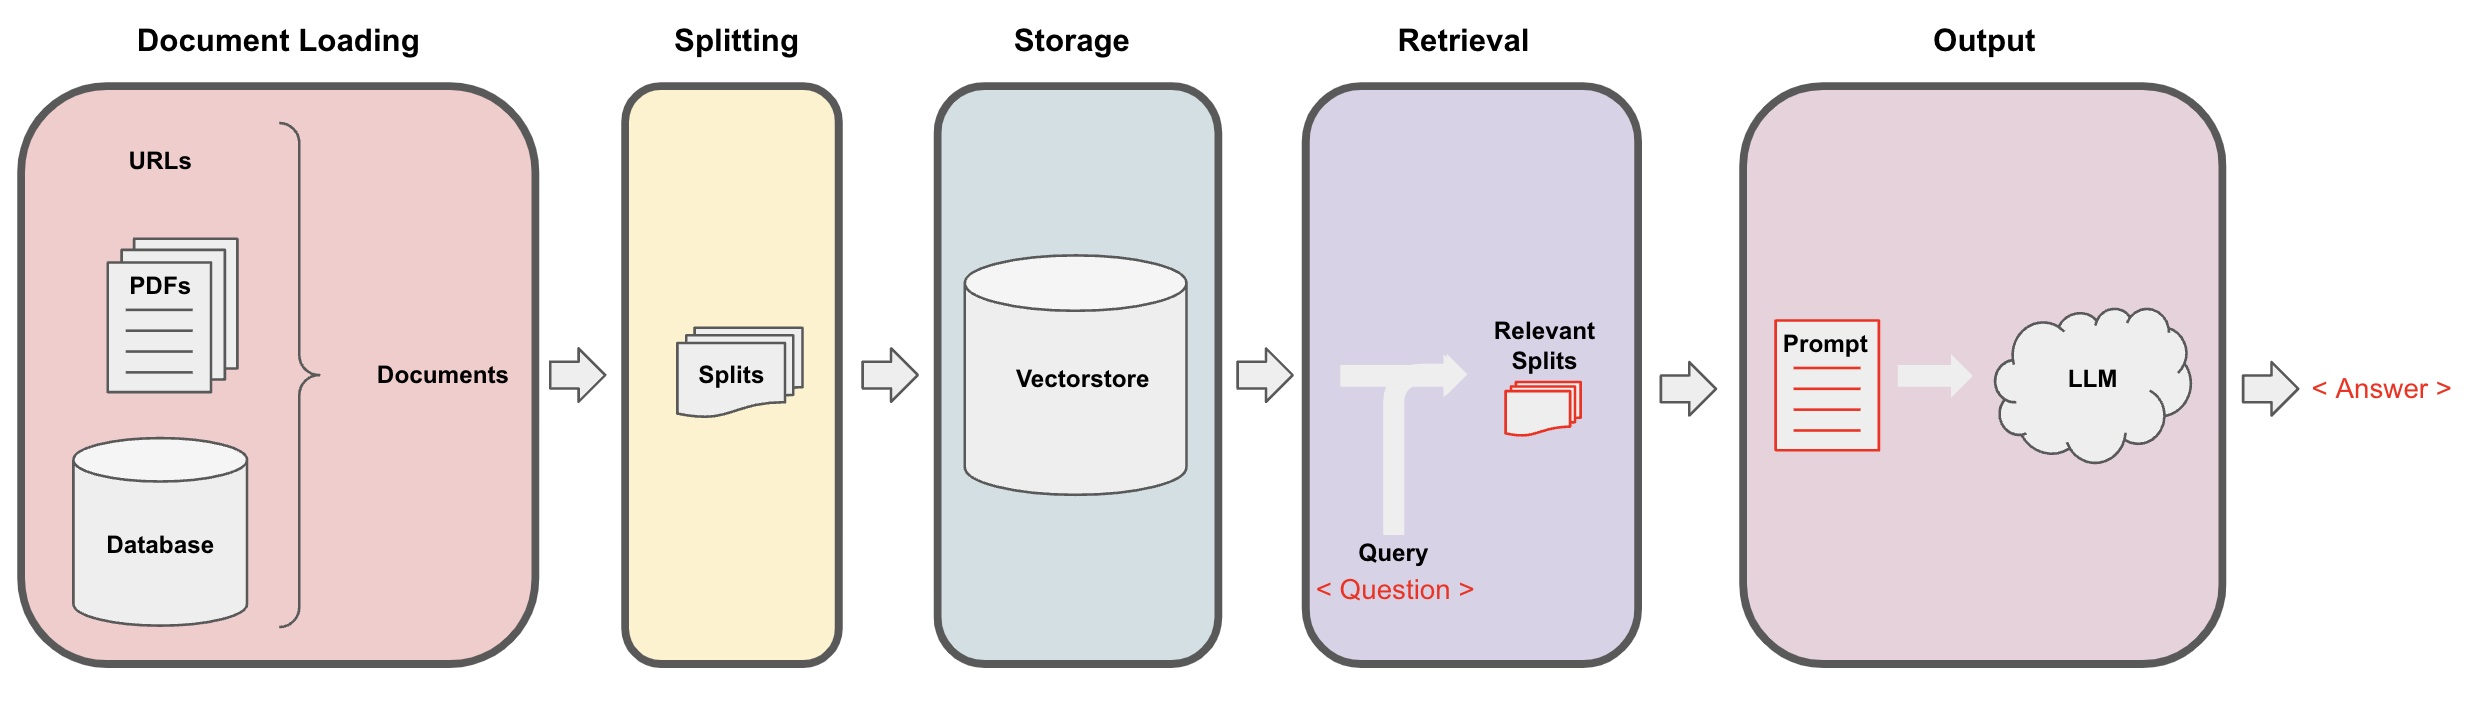

## Document Loading

In [1]:
! pip install langchain openai pypdf langchain-community pydub yt_dlp chromadb lark


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import openai
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()

# os.environ["OPENAI_API_KEY"]   = user_secrets.get_secret("OPENAI_API_KEY")

### PDFs

Let's load a PDF [transcript](https://see.stanford.edu/materials/aimlcs229/transcripts/MachineLearning-Lecture01.pdf) from Andrew Ng's famous CS229 course!

In [3]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("MachineLearning-Lecture01.pdf")
pages = loader.load()

C:\Users\lkidane\AppData\Local\Temp\ipykernel_12148\1718709764.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\lkidane\Documents\Projects\langgraph-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Each page is a `Document`.

A `Document` contains text (`page_content`) and `metadata`.

In [4]:
len(pages)

22

In [5]:
page = pages[0]

In [6]:
print(page.page_content[0:500])

MachineLearning-Lecture01  
Instructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine 
learning class. So what I wanna do today is just spend a little time going over the logistics 
of the class, and then we'll start to talk a bit about machine learning.  
By way of introduction, my name's Andrew Ng and I'll be instructor for this class. And so 
I personally work in machine learning, and I've worked on it for about 15 years now, and 
I actually think that machine learning is the 


In [7]:
page.metadata

{'producer': 'PDFium',
 'creator': 'PDFium',
 'creationdate': 'D:20260629085413',
 'source': 'MachineLearning-Lecture01.pdf',
 'total_pages': 22,
 'page': 0,
 'page_label': '1'}

### YouTube

In [8]:
from langchain_community.document_loaders.generic import GenericLoader
from langchain_community.document_loaders.blob_loaders.file_system import FileSystemBlobLoader

from langchain_community.document_loaders.parsers import OpenAIWhisperParser
from langchain_community.document_loaders.blob_loaders.youtube_audio import YoutubeAudioLoader

In [9]:
# ! pip install yt_dlp
# ! pip install pydub

In [10]:
# url="https://www.youtube.com/watch?v=jGwO_UgTS7I"
# save_dir="/kaggle/working/"
# loader = GenericLoader(
#     YoutubeAudioLoader([url],save_dir),  # fetch from youtube
#     # FileSystemBlobLoader(save_dir, glob="*.m4a"),   #fetch locally
#     OpenAIWhisperParser()
# )
# docs = loader.load()

In [11]:
# docs[0].page_content[0:500]

### URLs

In [12]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://github.com/basecamp/handbook/blob/master/titles-for-programmers.md")

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [13]:
docs = loader.load()

In [14]:
print(docs[0].page_content[:500])



















































































































handbook/titles-for-programmers.md at master · basecamp/handbook · GitHub


















































Skip to content














Navigation Menu

Toggle navigation




 













            Sign in
          


 


Appearance settings











PlatformAI CODE CREATIONGitHub CopilotWrite better code with AIGitHub Copilot appDirect agents from issue to m


## Document Splitting

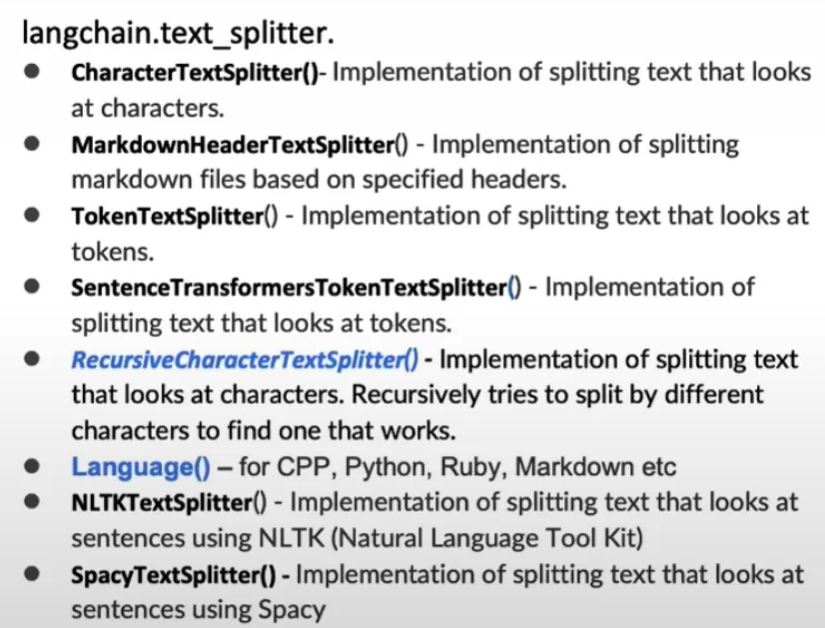

In [15]:
# from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter

In [16]:
chunk_size =26
chunk_overlap = 4

In [17]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)

In [18]:
text1 = 'abcdefghijklmnopqrstuvwxyz'

In [19]:
r_splitter.split_text(text1)

['abcdefghijklmnopqrstuvwxyz']

In [20]:
text2 = 'abcdefghijklmnopqrstuvwxyzabcdefg'

In [21]:
r_splitter.split_text(text2)

['abcdefghijklmnopqrstuvwxyz', 'wxyzabcdefg']

In [22]:
c_splitter.split_text(text2)

['abcdefghijklmnopqrstuvwxyzabcdefg']

In [23]:
text3 = "a b c d e f g h i j k l m n o p q r s t u v w x y z"

In [24]:
r_splitter.split_text(text3) 

['a b c d e f g h i j k l m', 'l m n o p q r s t u v w x', 'w x y z']

In [25]:
c_splitter.split_text(text3)

['a b c d e f g h i j k l m n o p q r s t u v w x y z']

In [26]:
c_splitter = CharacterTextSplitter(
    chunk_size=20,
    chunk_overlap=5,
    separator = ' '
)
c_splitter.split_text(text3)

['a b c d e f g h i j',
 'h i j k l m n o p q',
 'o p q r s t u v w x',
 'v w x y z']

`RecursiveCharacterTextSplitter` is recommended for generic text. 

In [27]:
some_text = """When writing documents, writers will use document structure to group content. \
This can convey to the reader, which idea's are related. For example, closely related ideas \
are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n  \
Paragraphs are often delimited with a carriage return or two carriage returns. \
Carriage returns are the "backslash n" you see embedded in this string. \
Sentences have a period at the end, but also, have a space.\
and words are separated by space."""

In [28]:
len(some_text)

496

In [29]:
c_splitter = CharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0,
    separator = ' '
)
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0, 
    separators=["\n\n", "\n", " ", ""]
)

In [30]:
c_splitter.split_text(some_text)

['When writing documents, writers will use document structure to group content. This can convey to the reader, which idea\'s are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also,',
 'have a space.and words are separated by space.']

In [31]:
r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.",
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

Let's reduce the chunk size a bit and add a period to our separators:

In [32]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "\. ", " ", ""]
)
r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example,",
 'closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this',
 'string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

In [33]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "(?<=\. )", " ", ""]
)
r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example,",
 'closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this',
 'string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

In [34]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("MachineLearning-Lecture01.pdf")
pages = loader.load()

In [35]:
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=150,
    length_function=len
)

In [36]:
docs = text_splitter.split_documents(pages)

In [37]:
docs[0].page_content

"MachineLearning-Lecture01  \nInstructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine \nlearning class. So what I wanna do today is just spend a little time going over the logistics \nof the class, and then we'll start to talk a bit about machine learning.  \nBy way of introduction, my name's Andrew Ng and I'll be instructor for this class. And so \nI personally work in machine learning, and I've worked on it for about 15 years now, and \nI actually think that machine learning is the most exciting field of all the computer \nsciences. So I'm actually always excited about teaching this class. Sometimes I actually \nthink that machine learning is not only the most exciting thing in computer science, but \nthe most exciting thing in all of human endeavor, so maybe a little bias there.  \nI also want to introduce the TAs, who are all graduate students doing research in or \nrelated to the machine learning and all aspects of machine learning. Paul Baumstarck"

In [38]:
len(docs)

78

In [39]:
len(pages)

22

### Token splitting

We can also split on token count explicity, if we want.

This can be useful because LLMs often have context windows designated in tokens.

Tokens are often ~4 characters.

In [40]:
from langchain_text_splitters import TokenTextSplitter

In [41]:
text_splitter = TokenTextSplitter(chunk_size=1, chunk_overlap=0)

In [42]:
text1 = "foo bar bazzyfoo"

In [43]:
text_splitter.split_text(text1)

['foo', ' bar', ' b', 'az', 'zy', 'foo']

In [44]:
text_splitter = TokenTextSplitter(chunk_size=10, chunk_overlap=0)

In [45]:
docs = text_splitter.split_documents(pages)

In [46]:
docs[0]

Document(metadata={'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': 'D:20260629085413', 'source': 'MachineLearning-Lecture01.pdf', 'total_pages': 22, 'page': 0, 'page_label': '1'}, page_content='MachineLearning-Lecture01  \n')

In [47]:
pages[0].metadata

{'producer': 'PDFium',
 'creator': 'PDFium',
 'creationdate': 'D:20260629085413',
 'source': 'MachineLearning-Lecture01.pdf',
 'total_pages': 22,
 'page': 0,
 'page_label': '1'}

### Context aware splitting

Chunking aims to keep text with common context together.

A text splitting often uses sentences or other delimiters to keep related text together but many documents (such as Markdown) have structure (headers) that can be explicitly used in splitting.

We can use `MarkdownHeaderTextSplitter` to preserve header metadata in our chunks, as show below.

In [48]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

In [49]:
markdown_document = """# Title\n\n \
## Chapter 1\n\n \
Hi this is Jim\n\n Hi this is Joe\n\n \
### Section \n\n \
Hi this is Lance \n\n 
## Chapter 2\n\n \
Hi this is Molly"""

In [50]:
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

In [51]:
markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on
)
md_header_splits = markdown_splitter.split_text(markdown_document)

In [52]:
md_header_splits[0]

Document(metadata={'Header 1': 'Title', 'Header 2': 'Chapter 1'}, page_content='Hi this is Jim  \nHi this is Joe')

In [53]:
md_header_splits[1]

Document(metadata={'Header 1': 'Title', 'Header 2': 'Chapter 1', 'Header 3': 'Section'}, page_content='Hi this is Lance')

## Vectorstores and Embeddings

In [54]:
from langchain_community.document_loaders import PyPDFLoader

# Load PDF
loaders = [
    # Duplicate documents on purpose - messy data
    PyPDFLoader("MachineLearning-Lecture01.pdf"),
    PyPDFLoader("MachineLearning-Lecture01.pdf"),
    PyPDFLoader("MachineLearning-Lecture02.pdf"),
    PyPDFLoader("MachineLearning-Lecture03.pdf")
]
docs = []
for loader in loaders:
    docs.extend(loader.load())

In [55]:
# Split
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 150
)

In [56]:
splits = text_splitter.split_documents(docs)

In [57]:
len(splits)

208

### Embeddings

In [58]:
!pip install sentence-transformers


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
# from langchain.embeddings.openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(
    model_name="nomic-ai/nomic-embed-text-v1"
)
# embedding = OpenAIEmbeddings()

C:\Users\lkidane\AppData\Local\Temp\ipykernel_12148\3116734002.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 112/112 [00:00<00:00, 9274.85it/s]


In [60]:
sentence1 = "i like dogs"
sentence2 = "i like canines"
sentence3 = "the weather is ugly outside"

In [61]:
embedding1 = embedding.embed_query(sentence1)
embedding2 = embedding.embed_query(sentence2)
embedding3 = embedding.embed_query(sentence3)

In [62]:
import numpy as np

In [63]:
np.dot(embedding1, embedding2)

np.float64(0.9093407977393271)

In [64]:
np.dot(embedding2, embedding3)

np.float64(0.32460216399927466)

In [65]:
np.dot(embedding1, embedding3)

np.float64(0.3378753044598122)

### Vectorstores

In [66]:
from langchain_community.vectorstores import Chroma


In [67]:
persist_directory = '/kaggle/working/chroma/'

In [68]:
!rm -rf ./kaggle/working/chroma  # remove old database files if any

'rm' is not recognized as an internal or external command,
operable program or batch file.


In [69]:
vectordb = Chroma.from_documents(
    documents=splits,
    embedding=embedding,
    persist_directory=persist_directory
)

In [70]:
print(vectordb._collection.count())

416


### Similarity Search

In [71]:
question = "is there an email i can ask for help"

In [72]:
docs = vectordb.similarity_search(question,k=3)

In [73]:
len(docs)

3

In [74]:
docs[0].page_content

"cs229-qa@cs.stanford.edu. This goes to an account that's read by all the TAs and me. So \nrather than sending us email individually, if you send email to this account, it will \nactually let us get back to you maximally quickly with answers to your questions.  \nIf you're asking questions about homework problems, please say in the subject line which \nassignment and which question the email refers to, since that will also help us to route \nyour question to the appropriate TA or to me appropriately and get the response back to \nyou quickly.  \nLet's see. Skipping ahead — let's see — for homework, one midterm, one open and term \nproject. Notice on the honor code. So one thing that I think will help you to succeed and \ndo well in this class and even help you to enjoy this class more is if you form a study \ngroup.  \nSo start looking around where you're sitting now or at the end of class today, mingle a \nlittle bit and get to know your classmates. I strongly encourage you to form st

## Failure modes

This seems great, and basic similarity search will get you 80% of the way there very easily. 

But there are some failure modes that can creep up. 

Here are some edge cases that can arise 

In [75]:
question = "what did they say about matlab?"

In [76]:
docs = vectordb.similarity_search(question,k=5)

In [77]:
docs[0]

Document(metadata={'page_label': '9', 'source': 'MachineLearning-Lecture01.pdf', 'creator': 'PDFium', 'total_pages': 22, 'creationdate': 'D:20260629085413', 'page': 8, 'producer': 'PDFium'}, page_content='those homeworks will be done in either MATLAB or in Octave, which is sort of — I \nknow some people call it a free version of MATLAB, which it sort of is, sort of isn\'t.  \nSo I guess for those of you that haven\'t seen MATLAB before, and I know most of you \nhave, MATLAB is I guess part of the programming language that makes it very easy to \nwrite codes using matrices, to write code for numerical routines, to move data around, to \nplot data. And it\'s sort of an extremely easy to learn tool to use for implementing a lot of \nlearning algorithms.  \nAnd in case some of you want to work on your own home computer or something if you \ndon\'t have a MATLAB license, for the purposes of this class, there\'s also — [inaudible] \nwrite that down [inaudible] MATLAB — there\' s also a softw

In [78]:
docs[1]

Document(metadata={'total_pages': 22, 'page': 8, 'source': 'MachineLearning-Lecture01.pdf', 'producer': 'PDFium', 'creationdate': 'D:20260629085413', 'creator': 'PDFium', 'page_label': '9'}, page_content='those homeworks will be done in either MATLAB or in Octave, which is sort of — I \nknow some people call it a free version of MATLAB, which it sort of is, sort of isn\'t.  \nSo I guess for those of you that haven\'t seen MATLAB before, and I know most of you \nhave, MATLAB is I guess part of the programming language that makes it very easy to \nwrite codes using matrices, to write code for numerical routines, to move data around, to \nplot data. And it\'s sort of an extremely easy to learn tool to use for implementing a lot of \nlearning algorithms.  \nAnd in case some of you want to work on your own home computer or something if you \ndon\'t have a MATLAB license, for the purposes of this class, there\'s also — [inaudible] \nwrite that down [inaudible] MATLAB — there\' s also a softw

Notice that we're getting duplicate chunks (because of the duplicate `MachineLearning-Lecture01.pdf` in the index).

Semantic search fetches all similar documents, but does not enforce diversity.

`docs[0]` and `docs[1]` are indentical.

In [79]:
question = "what did they say about regression in the third lecture?"

In [80]:
docs = vectordb.similarity_search(question,k=5)

In [81]:
for doc in docs:
    print(doc.metadata)

{'title': '', 'page': 0, 'creationdate': '2008-07-11T11:25:03-07:00', 'source': 'MachineLearning-Lecture03.pdf', 'page_label': '1', 'total_pages': 16, 'creator': 'PScript5.dll Version 5.2.2', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'moddate': '2008-07-11T11:25:03-07:00', 'author': ''}
{'creator': 'PScript5.dll Version 5.2.2', 'author': '', 'total_pages': 16, 'page': 0, 'title': '', 'moddate': '2008-07-11T11:25:03-07:00', 'page_label': '1', 'source': 'MachineLearning-Lecture03.pdf', 'creationdate': '2008-07-11T11:25:03-07:00', 'producer': 'Acrobat Distiller 8.1.0 (Windows)'}
{'total_pages': 18, 'author': '', 'creationdate': '2008-07-11T11:25:05-07:00', 'title': '', 'page_label': '3', 'page': 2, 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'source': 'MachineLearning-Lecture02.pdf', 'creator': 'PScript5.dll Version 5.2.2', 'moddate': '2008-07-11T11:25:05-07:00'}
{'page_label': '3', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'title': '', 'total_pages': 18, 'creationdate'

In [82]:
print(docs[4].page_content)

Student:It’s the lowest it –  
Instructor (Andrew Ng):No, exactly. Right. So zero to the same, this is not the same, 
right? And the reason is, in logistic regression this is different from before, right? The 
definition of this H subscript theta of XI is not the same as the definition I was using in 
the previous lecture. And in particular this is no longer theta transpose XI. This is not a 
linear function anymore. This is a logistic function of theta transpose XI. Okay? So even 
though this looks cosmetically similar, even though this is similar on the surface, to the 
Bastrian descent rule I derived last time for least squares regression this is actually a 
totally different learning algorithm. Okay? And it turns out that there’s actually no 
coincidence that you ended up with the same learning rule. We’ll actually talk a bit more 
about this later when we talk about generalized linear models. But this is one of the most 
elegant generalized learning models that we’ll see later. Th

## Retrieval

Retrieval is the centerpiece of our retrieval augmented generation (RAG) flow. 

Let's get our vectorDB from before.

### Similarity Search

In [83]:
from langchain_community.vectorstores import Chroma
# from langchain.embeddings.openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

persist_directory = 'chroma/'

In [84]:
# embedding = OpenAIEmbeddings()
embedding = HuggingFaceEmbeddings(
    model_name="nomic-ai/nomic-embed-text-v1"
)
vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)

Loading weights: 100%|██████████| 112/112 [00:00<00:00, 4861.25it/s]
C:\Users\lkidane\AppData\Local\Temp\ipykernel_12148\828281087.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(


In [85]:
print(vectordb._collection.count())

0


In [86]:
texts = [
    """The Amanita phalloides has a large and imposing epigeous (aboveground) fruiting body (basidiocarp).""",
    """A mushroom with a large fruiting body is the Amanita phalloides. Some varieties are all-white.""",
    """A. phalloides, a.k.a Death Cap, is one of the most poisonous of all known mushrooms.""",
]

In [87]:
smalldb = Chroma.from_texts(texts, embedding=embedding)

In [88]:
question = "Tell me about all-white mushrooms with large fruiting bodies"

In [89]:
smalldb.similarity_search(question, k=2)

[Document(metadata={}, page_content='A mushroom with a large fruiting body is the Amanita phalloides. Some varieties are all-white.'),
 Document(metadata={}, page_content='The Amanita phalloides has a large and imposing epigeous (aboveground) fruiting body (basidiocarp).')]

In [90]:
smalldb.max_marginal_relevance_search(question,k=2, fetch_k=3)

[Document(metadata={}, page_content='A mushroom with a large fruiting body is the Amanita phalloides. Some varieties are all-white.'),
 Document(metadata={}, page_content='A. phalloides, a.k.a Death Cap, is one of the most poisonous of all known mushrooms.')]

### Addressing Diversity: Maximum marginal relevance

Last class we introduced one problem: how to enforce diversity in the search results.
 
`Maximum marginal relevance` strives to achieve both relevance to the query *and diversity* among the results.

In [91]:
question = "what did they say about matlab?"
docs_ss = vectordb.similarity_search(question,k=3)

In [ ]:
# docs_ss[0].page_content[:100]

IndexError: list index out of range

In [ ]:
# docs_ss[1].page_content[:100]

IndexError: list index out of range

Note the difference in results with `MMR`.

In [94]:
docs_mmr = vectordb.max_marginal_relevance_search(question,k=3)

In [ ]:
# docs_mmr[0].page_content[:100]

In [ ]:
# docs_mmr[1].page_content[:100]

### Addressing Specificity: working with metadata

In last lecture, we showed that a question about the third lecture can include results from other lectures as well.

To address this, many vectorstores support operations on `metadata`.

`metadata` provides context for each embedded chunk.

In [96]:
question = "what did they say about regression in the third lecture?"

In [97]:
docs = vectordb.similarity_search(
    question,
    k=3,
    filter={"source":"docs/cs229_lectures/MachineLearning-Lecture03.pdf"}
)

In [98]:
for d in docs:
    print(d.metadata)

### Addressing Specificity: working with metadata using self-query retriever

But we have an interesting challenge: we often want to infer the metadata from the query itself.

To address this, we can use `SelfQueryRetriever`, which uses an LLM to extract:
 
1. The `query` string to use for vector search
2. A metadata filter to pass in as well

Most vector databases support metadata filters, so this doesn't require any new databases or indexes.

In [101]:
# from langchain.llms import OpenAI
from langchain.retrievers.self_query.base import SelfQueryRetriever
from langchain.chains.query_constructor.base import AttributeInfo

ModuleNotFoundError: No module named 'langchain.retrievers'

In [ ]:
from langchain_community.retrievers.self_query.base import SelfQueryRetriever
from langchain.chains.query_constructor.base import AttributeInfo

print("✅ Correct imports finally working")

ImportError: cannot import name 'SelfQueryRetriever' from 'langchain_experimental.retrievers' (c:\Users\lkidane\Documents\Projects\langgraph-course\.venv\Lib\site-packages\langchain_experimental\retrievers\__init__.py)

In [ ]:
metadata_field_info = [
    AttributeInfo(
        name="source",
        description="The lecture the chunk is from, should be one of `docs/cs229_lectures/MachineLearning-Lecture01.pdf`, `docs/cs229_lectures/MachineLearning-Lecture02.pdf`, or `docs/cs229_lectures/MachineLearning-Lecture03.pdf`",
        type="string",
    ),
    AttributeInfo(
        name="page",
        description="The page from the lecture",
        type="integer",
    ),
]

**Note:** The default model for `OpenAI` ("from langchain.llms import OpenAI") is `text-davinci-003`. Due to the deprication of OpenAI's model `text-davinci-003` on 4 January 2024, you'll be using OpenAI's recommended replacement model `gpt-3.5-turbo-instruct` instead.

In [ ]:
!pip install lark

In [ ]:
document_content_description = "Lecture notes"
llm = OpenAI(model='gpt-3.5-turbo-instruct', temperature=0)
retriever = SelfQueryRetriever.from_llm(
    llm,
    vectordb,
    document_content_description,
    metadata_field_info,
    verbose=True
)

In [ ]:
question = "what did they say about regression in the third lecture?"

**You will receive a warning** about predict_and_parse being deprecated the first time you executing the next line. This can be safely ignored.

In [ ]:
docs = retriever.get_relevant_documents(question)

In [ ]:
for d in docs:
    print(d.metadata)

### Additional tricks: compression

Another approach for improving the quality of retrieved docs is compression.

Information most relevant to a query may be buried in a document with a lot of irrelevant text. 

Passing that full document through your application can lead to more expensive LLM calls and poorer responses.

Contextual compression is meant to fix this. 

In [ ]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor

In [ ]:
def pretty_print_docs(docs):
    print(f"\n{'-' * 100}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(docs)]))

In [ ]:
# Wrap our vectorstore
llm = OpenAI(temperature=0, model="gpt-3.5-turbo-instruct")
compressor = LLMChainExtractor.from_llm(llm)

In [ ]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=vectordb.as_retriever()
)

In [ ]:
question = "what did they say about matlab?"
compressed_docs = compression_retriever.get_relevant_documents(question)
pretty_print_docs(compressed_docs)

## Combining various techniques

In [ ]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=vectordb.as_retriever(search_type = "mmr")
)

In [ ]:
question = "what did they say about matlab?"
compressed_docs = compression_retriever.get_relevant_documents(question)
pretty_print_docs(compressed_docs)

## ********Other types of retrieval

It's worth noting that vectordb as not the only kind of tool to retrieve documents. 

The `LangChain` retriever abstraction includes other ways to retrieve documents, such as TF-IDF or SVM.

In [ ]:
from langchain.retrievers import SVMRetriever
from langchain.retrievers import TFIDFRetriever
from langchain.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
# Load PDF
loader = PyPDFLoader("/kaggle/input/rag-with-langchain-deeplearning-ai/MachineLearning-Lecture01.pdf")
pages = loader.load()
all_page_text=[p.page_content for p in pages]
joined_page_text=" ".join(all_page_text)

# Split
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1500,chunk_overlap = 150)
splits = text_splitter.split_text(joined_page_text)


In [ ]:
# Retrieve
svm_retriever = SVMRetriever.from_texts(splits,embedding)
tfidf_retriever = TFIDFRetriever.from_texts(splits)

In [ ]:
question = "What are major topics for this class?"
docs_svm=svm_retriever.get_relevant_documents(question)
docs_svm[0]

In [ ]:
question = "what did they say about matlab?"
docs_tfidf=tfidf_retriever.get_relevant_documents(question)
docs_tfidf[0]

## Question Answering

The code below was added to assign the openai LLM version filmed until it is deprecated, currently in Sept 2023. 
LLM responses can often vary, but the responses may be significantly different when using a different model version.

In [ ]:
import datetime
current_date = datetime.datetime.now().date()
if current_date < datetime.date(2023, 9, 2):
    llm_name = "gpt-3.5-turbo-0301"
else:
    llm_name = "gpt-3.5-turbo"
print(llm_name)    

In [ ]:
from langchain.vectorstores import Chroma
from langchain.embeddings.openai import OpenAIEmbeddings
persist_directory = 'docs/chroma/'
embedding = OpenAIEmbeddings()
vectordb = Chroma(persist_directory=persist_directory, embedding_function=embedding)

In [ ]:
print(vectordb._collection.count())

In [ ]:
question = "What are major topics for this class?"
docs = vectordb.similarity_search(question,k=3)
len(docs)

In [ ]:
from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(model_name=llm_name, temperature=0)

### RetrievalQA chain

In [ ]:
from langchain.chains import RetrievalQA

In [ ]:
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever()
)

In [ ]:
result = qa_chain({"query": question})

In [ ]:
result["result"]

### Prompt

In [ ]:
from langchain.prompts import PromptTemplate

# Build prompt
template = """Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer. 
{context}
Question: {question}
Helpful Answer:"""
QA_CHAIN_PROMPT = PromptTemplate.from_template(template)


In [ ]:
# Run chain
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    return_source_documents=True,
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
)

In [ ]:
question = "Is probability a class topic?"

In [ ]:
result = qa_chain({"query": question})

In [ ]:
result["result"]

In [ ]:
result["source_documents"][0]

### RetrievalQA chain types

In [ ]:
qa_chain_mr = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    chain_type="map_reduce"
)

In [ ]:
result = qa_chain_mr({"query": question})

In [ ]:
result["result"]

In [ ]:
import os
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.langchain.plus"
os.environ["LANGCHAIN_API_KEY"] = user_secrets.get_secret("LANGCHAIN_API_KEY")
LANGCHAIN_PROJECT="Learning RAG"

In [ ]:
qa_chain_mr = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    chain_type="map_reduce"
)
result = qa_chain_mr({"query": question})
result["result"]

In [ ]:
qa_chain_mr = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    chain_type="refine"
)
result = qa_chain_mr({"query": question})
result["result"]

### RetrievalQA limitations
 
QA fails to preserve conversational history.

In [ ]:
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever()
)

In [ ]:
question = "Is probability a class topic?"
result = qa_chain({"query": question})
result["result"]

In [ ]:
question = "why are those prerequesites needed?"
result = qa_chain({"query": question})
result["result"]

## Chat

In [105]:
!pip install jupyter_bokeh docarray

  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 9.8 MB/s  0:00:00
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ------------- -------------------------- 2.1/6.4 MB 11.8 MB/s eta 0:00:01
   ----------------------------- ---------- 4.7/6.4 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 6.4/6.4 MB 11.2 MB/s  0:00:00
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 8.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------------------------------- - 2.1/2.2 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 10.3 MB/s  0:00:00
Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl (7.1 MB)

   --- ------------------------------------  1/12 [widget


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [107]:
import panel as pn  # GUI
pn.extension()

In [108]:
import datetime
current_date = datetime.datetime.now().date()
if current_date < datetime.date(2023, 9, 2):
    llm_name = "gpt-3.5-turbo-0301"
else:
    llm_name = "gpt-3.5-turbo"
print(llm_name)

gpt-3.5-turbo


In [ ]:
import os
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_ENDPOINT"] = "https://api.langchain.plus"
# os.environ["LANGCHAIN_API_KEY"] = user_secrets.get_secret("LANGCHAIN_API_KEY")
# os.environ["LANGCHAIN_PROJECT"]="Learning RAG"

In [110]:
from langchain_community.vectorstores import Chroma
# from langchain.embeddings.openai import OpenAIEmbeddings
persist_directory = 'chroma/'
from langchain_community.embeddings import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(
    model_name="nomic-ai/nomic-embed-text-v1"
)
# embedding = OpenAIEmbeddings()
vectordb = Chroma(persist_directory=persist_directory, embedding_function=embedding)

Loading weights: 100%|██████████| 112/112 [00:00<00:00, 4584.34it/s]


In [111]:
question = "What are major topics for this class?"
docs = vectordb.similarity_search(question,k=3)
len(docs)

0

In [114]:
# from langchain.chat_models import ChatOpenAI
from langchain_ollama import ChatOllama

# llm = ChatOpenAI(model_name=llm_name, temperature=0)
# ✅ changed LLM
llm = ChatOllama(model="mymodel") 
llm.invoke("Hello world!")

AIMessage(content='Hello, world! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'mymodel', 'created_at': '2026-06-29T08:54:08.8658705Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8641189800, 'load_duration': 8279161400, 'prompt_eval_count': 11, 'prompt_eval_duration': 146087000, 'eval_count': 14, 'eval_duration': 192395000, 'logprobs': None, 'model_name': 'mymodel', 'model_provider': 'ollama'}, id='lc_run--019f1295-e024-70d1-a145-c17636309994-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 14, 'total_tokens': 25})

In [120]:
# Build prompt
from langchain_core.prompts import PromptTemplate

template = """Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer. 
{context}
Question: {question}
Helpful Answer:"""
QA_CHAIN_PROMPT = PromptTemplate(input_variables=["context", "question"],template=template,)

# Run chain
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
# question = "Is probability a class topic?"
# qa_chain = RetrievalQA.from_chain_type(llm,
#                                        retriever=vectordb.as_retriever(),
#                                        return_source_documents=True,
#                                        chain_type_kwargs={"prompt": QA_CHAIN_PROMPT})


# result = qa_chain({"query": question})
# result["result"]



retriever = vectordb.as_retriever()

# Build chain
qa_chain = (
    {
        "context": retriever,               # gets docs from retriever
        "question": RunnablePassthrough()   # passes input question through
    }
    | QA_CHAIN_PROMPT                       # formats prompt
    | llm                                   # calls LLM
    | StrOutputParser()                     # converts output to string
)

# Run
question = "Is probability a class topic?"
result = qa_chain.invoke(question)

print(result)


Yes, probability is a class topic.


### Memory

In [122]:
# from langchain.memory import ConversationBufferMemory
# memory = ConversationBufferMemory(
#     memory_key="chat_history",
#     return_messages=True
# )

### ConversationalRetrievalChain

In [124]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# retriever
retriever = vectordb.as_retriever()

# simple history store
chat_history = []

def format_history(history):
    return "\n".join([f"{role}: {msg}" for role, msg in history])

# chain
qa_chain = (
    {
        "context": retriever,
        "question": RunnablePassthrough(),
        "chat_history": lambda _: format_history(chat_history),
    }
    | QA_CHAIN_PROMPT
    | llm
    | StrOutputParser()
)

# function to simulate conversation
def ask(question):
    answer = qa_chain.invoke(question)
    chat_history.append(("user", question))
    chat_history.append(("assistant", answer))
    return answer

In [127]:
question = "Is probability a class topic?"
result = ask( question)

In [131]:
# result['assistant']
result

"Yes it is. It's considered one of the main components in statistics courses. Thanks for asking!"

In [132]:
question = "why are those prerequesites needed?"
result = ask( question)

In [134]:
result

'Those prerequisites exist so students can get more out of their learning experience. They help ensure that students have the necessary background knowledge to tackle a course. Thanks for asking!'

# Create a chatbot that works on your documents

In [ ]:
# from langchain.embeddings.openai import OpenAIEmbeddings
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain.vectorstores import DocArrayInMemorySearch
from langchain.document_loaders import TextLoader
from langchain.chains import RetrievalQA,  ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory
from langchain.chat_models import ChatOpenAI
from langchain.document_loaders import TextLoader
from langchain.document_loaders import PyPDFLoader

In [ ]:
def load_db(file, chain_type, k):
    # load documents
    loader = PyPDFLoader(file)
    documents = loader.load()
    # split documents
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
    docs = text_splitter.split_documents(documents)
    # define embedding
    embeddings = OpenAIEmbeddings()
    # create vector database from data
    db = DocArrayInMemorySearch.from_documents(docs, embeddings)
    # define retriever
    retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": k})
    # create a chatbot chain. Memory is managed externally.
    qa = ConversationalRetrievalChain.from_llm(
        llm=ChatOpenAI(model_name=llm_name, temperature=0), 
        chain_type=chain_type, 
        retriever=retriever, 
        return_source_documents=True,
        return_generated_question=True,
    )
    return qa 


In [141]:
import panel as pn
import param

class cbfs(param.Parameterized):
    chat_history = param.List([])
    answer = param.String("")
    db_query  = param.String("")
    db_response = param.List([])
    
    def __init__(self,  **params):
        super(cbfs, self).__init__( **params)
        self.panels = []
        self.loaded_file = "/kaggle/input/rag-with-langchain-deeplearning-ai/MachineLearning-Lecture01.pdf"
        self.qa = load_db(self.loaded_file,"stuff", 4)
    
    def call_load_db(self, count):
        if count == 0 or file_input.value is None:  # init or no file specified :
            return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")
        else:
            file_input.save("temp.pdf")  # local copy
            self.loaded_file = file_input.filename
            button_load.button_style="outline"
            self.qa = load_db("temp.pdf", "stuff", 4)
            button_load.button_style="solid"
        self.clr_history()
        return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")

    def convchain(self, query):
        if not query:
            return pn.WidgetBox(pn.Row('User:', pn.pane.Markdown("", width=600)), scroll=True)
        result = self.qa({"question": query, "chat_history": self.chat_history})
        self.chat_history.extend([(query, result["answer"])])
        self.db_query = result["generated_question"]
        self.db_response = result["source_documents"]
        self.answer = result['answer'] 
        self.panels.extend([
            pn.Row('User:', pn.pane.Markdown(query, width=600)),
            pn.Row('ChatBot:', pn.pane.Markdown(
        f"<div style='background-color:#F6F6F6;padding:8px;border-radius:6px'>{self.answer}</div>",
        width=600))
        ])
        inp.value = ''  #clears loading indicator when cleared
        return pn.WidgetBox(*self.panels,scroll=True)

    @param.depends('db_query ', )
    def get_lquest(self):
        if not self.db_query :
            return pn.Column(
                pn.Row(pn.pane.Markdown(f"Last question to DB:", styles={'background-color': '#F6F6F6'})),
                pn.Row(pn.pane.Str("no DB accesses so far"))
            )
        return pn.Column(
            pn.Row(pn.pane.Markdown(f"DB query:", styles={'background-color': '#F6F6F6'})),
            pn.pane.Str(self.db_query )
        )

    @param.depends('db_response', )
    def get_sources(self):
        if not self.db_response:
            return 
        rlist=[pn.Row(pn.pane.Markdown(f"Result of DB lookup:", styles={'background-color': '#F6F6F6'}))]
        for doc in self.db_response:
            rlist.append(pn.Row(pn.pane.Str(doc)))
        return pn.WidgetBox(*rlist, width=600, scroll=True)

    @param.depends('convchain', 'clr_history') 
    def get_chats(self):
        if not self.chat_history:
            return pn.WidgetBox(pn.Row(pn.pane.Str("No History Yet")), width=600, scroll=True)
        rlist=[pn.Row(pn.pane.Markdown(f"Current Chat History variable", styles={'background-color': '#F6F6F6'}))]
        for exchange in self.chat_history:
            rlist.append(pn.Row(pn.pane.Str(exchange)))
        return pn.WidgetBox(*rlist, width=600, scroll=True)

    def clr_history(self,count=0):
        self.chat_history = []
        return 


In [144]:
# ✅ Imports (LangChain 1.x)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import DocArrayInMemorySearch
from langchain_community.document_loaders import PyPDFLoader

from langchain_openai import OpenAIEmbeddings, ChatOpenAI

from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_community.embeddings import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(
    model_name="nomic-ai/nomic-embed-text-v1"
)

# from langchain.chat_models import ChatOpenAI
from langchain_ollama import ChatOllama

# llm = ChatOpenAI(model_name=llm_name, temperature=0)
# ✅ changed LLM
llm = ChatOllama(model="mymodel") 
# llm.invoke("Hello world!")

import panel as pn
import param

# # ✅ Set your model name
# llm_name = "gpt-3.5-turbo"


# ✅ Load DB + Build Runnable Chain
def load_db(file, k):
    loader = PyPDFLoader(file)
    documents = loader.load()

    # Split
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150
    )
    docs = text_splitter.split_documents(documents)

    # # Embeddings
    # embeddings = OpenAIEmbeddings()

    # Vector DB
    db = DocArrayInMemorySearch.from_documents(docs, embeddings)

    # Retriever
    retriever = db.as_retriever(
        search_type="similarity",
        search_kwargs={"k": k}
    )

    # Prompt
    template = """Use the following context to answer the question.
If you don't know the answer, say you don't know.

{context}

Question: {question}
Answer:"""

    prompt = PromptTemplate.from_template(template)

    # LLM
    # llm = ChatOpenAI(model_name=llm_name, temperature=0)

    # Format docs
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # ✅ Runnable chain (modern replacement for RetrievalQA)
    chain = (
        {
            "context": retriever | format_docs,
            "question": RunnablePassthrough()
        }
        | prompt
        | llm
        | StrOutputParser()
    )

    return chain, retriever


# ✅ Panel Chat App
class cbfs(param.Parameterized):

    chat_history = param.List([])
    answer = param.String("")
    db_query = param.String("")
    db_response = param.List([])

    def __init__(self, **params):
        super(cbfs, self).__init__(**params)

        self.panels = []
        self.loaded_file = "MachineLearning-Lecture01.pdf"

        self.qa, self.retriever = load_db(self.loaded_file, 4)

    # ✅ Load new PDF
    def call_load_db(self, count):
        if count == 0 or file_input.value is None:
            return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")

        file_input.save("temp.pdf")
        self.loaded_file = file_input.filename

        button_load.button_style = "outline"

        self.qa, self.retriever = load_db("temp.pdf", 4)

        button_load.button_style = "solid"

        self.clr_history()

        return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")

    # ✅ Chat logic (modern)
    def convchain(self, query):
        if not query:
            return pn.WidgetBox(
                pn.Row('User:', pn.pane.Markdown("", width=600)),
                scroll=True
            )

        # Run chain
        result = self.qa.invoke(query)

        # Retrieve docs manually (replacement for source_documents)
        docs = self.retriever.invoke(query)

        # Store history
        self.chat_history.append((query, result))

        self.db_query = query
        self.db_response = docs
        self.answer = result

        # Update UI
        self.panels.extend([
            pn.Row('User:', pn.pane.Markdown(query, width=600)),
            pn.Row(
                'ChatBot:',
                pn.pane.Markdown(
    f"<div style='background-color:#F6F6F6; padding:8px; border-radius:6px'>{self.answer}</div>",
    width=600,
)
            )
        ])

        inp.value = ""

        return pn.WidgetBox(*self.panels, scroll=True)

    # ✅ Last DB query
    @param.depends('db_query')
    def get_lquest(self):
        if not self.db_query:
            return pn.Column(
                pn.Row(pn.pane.Markdown("Last question to DB:")),
                pn.Row(pn.pane.Str("no DB accesses so far"))
            )

        return pn.Column(
            pn.Row(pn.pane.Markdown("DB query:")),
            pn.pane.Str(self.db_query)
        )

    # ✅ Sources
    @param.depends('db_response')
    def get_sources(self):
        if not self.db_response:
            return

        rlist = [pn.Row(pn.pane.Markdown("Result of DB lookup:"))]

        for doc in self.db_response:
            rlist.append(pn.Row(pn.pane.Str(doc.page_content[:200])))

        return pn.WidgetBox(*rlist, width=600, scroll=True)

    # ✅ Chat history viewer
    @param.depends('chat_history')
    def get_chats(self):
        if not self.chat_history:
            return pn.WidgetBox(
                pn.Row(pn.pane.Str("No History Yet")),
                width=600,
                scroll=True
            )

        rlist = [pn.Row(pn.pane.Markdown("Chat History"))]

        for exchange in self.chat_history:
            rlist.append(pn.Row(pn.pane.Str(exchange)))

        return pn.WidgetBox(*rlist, width=600, scroll=True)

    # ✅ Clear history
    def clr_history(self, count=0):
        self.chat_history = []
        return


Loading weights: 100%|██████████| 112/112 [00:00<00:00, 4449.56it/s]


In [145]:
import panel as pn
pn.extension()

# ✅ Initialize class
cb = cbfs()

# ✅ Widgets
file_input = pn.widgets.FileInput(accept='.pdf')
button_load = pn.widgets.Button(name="Load DB", button_type='primary')
button_clearhistory = pn.widgets.Button(name="Clear History", button_type='warning')

# ✅ Fix: bind clear history correctly
button_clearhistory.on_click(cb.clr_history)

inp = pn.widgets.TextInput(placeholder='Enter text here…')

# ✅ Bind functions
bound_button_load = pn.bind(cb.call_load_db, button_load.param.clicks)
conversation = pn.bind(cb.convchain, inp)

# ✅ Optional image (make sure file exists)
jpg_pane = pn.pane.Image('./img/convchain.jpg')

# ✅ Tabs

# Conversation tab
tab1 = pn.Column(
    pn.Row(inp),
    pn.layout.Divider(),
    pn.panel(conversation, loading_indicator=True, height=300),
    pn.layout.Divider(),
)

# DB tab
tab2 = pn.Column(
    pn.panel(cb.get_lquest),
    pn.layout.Divider(),
    pn.panel(cb.get_sources),
)

# Chat history tab
tab3 = pn.Column(
    pn.panel(cb.get_chats),
    pn.layout.Divider(),
)

# Config tab
tab4 = pn.Column(
    pn.Row(file_input, button_load, bound_button_load),
    pn.Row(
        button_clearhistory,
        pn.pane.Markdown("Clears chat history. Start a new topic")
    ),
    pn.layout.Divider(),
    pn.Row(jpg_pane.clone(width=400))
)

# ✅ Dashboard
dashboard = pn.Column(
    pn.Row(pn.pane.Markdown('# ChatWithYourData_Bot')),
    pn.Tabs(
        ('Conversation', tab1),
        ('Database', tab2),
        ('Chat History', tab3),
        ('Configure', tab4)
    )
)

dashboard

BokehModel(combine_events=True, render_bundle={'docs_json': {'e0ac44e1-95bf-4263-b952-d013def651cc': {'version…

### Create a chatbot

In [ ]:
cb = cbfs()

file_input = pn.widgets.FileInput(accept='.pdf')
button_load = pn.widgets.Button(name="Load DB", button_type='primary')
button_clearhistory = pn.widgets.Button(name="Clear History", button_type='warning')
button_clearhistory.on_click(cb.clr_history)
inp = pn.widgets.TextInput( placeholder='Enter text here…')

bound_button_load = pn.bind(cb.call_load_db, button_load.param.clicks)
conversation = pn.bind(cb.convchain, inp) 

jpg_pane = pn.pane.Image( './img/convchain.jpg')

tab1 = pn.Column(
    pn.Row(inp),
    pn.layout.Divider(),
    pn.panel(conversation,  loading_indicator=True, height=300),
    pn.layout.Divider(),
)
tab2= pn.Column(
    pn.panel(cb.get_lquest),
    pn.layout.Divider(),
    pn.panel(cb.get_sources ),
)
tab3= pn.Column(
    pn.panel(cb.get_chats),
    pn.layout.Divider(),
)
tab4=pn.Column(
    pn.Row( file_input, button_load, bound_button_load),
    pn.Row( button_clearhistory, pn.pane.Markdown("Clears chat history. Can use to start a new topic" )),
    pn.layout.Divider(),
    pn.Row(jpg_pane.clone(width=400))
)
dashboard = pn.Column(
    pn.Row(pn.pane.Markdown('# ChatWithYourData_Bot')),
    pn.Tabs(('Conversation', tab1), ('Database', tab2), ('Chat History', tab3),('Configure', tab4))
)
dashboard

In [ ]:
import langchain
print(langchain.__version__)

1.3.11
